In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


In [2]:
pd.set_option("display.max_columns",None)

df = pd.read_csv("EasyVisa.csv")

In [3]:
df.shape

(25480, 12)

In [4]:
feature_with_na = [features for features  in df.columns if df[features].isnull().sum()>= 1]
for feature in feature_with_na:
    print(feature,np.round(df[feature].isnull().mean()*100,5),'% missing values')

In [5]:
feature_with_na

[]

In [6]:
df.duplicated().sum()

0

In [7]:
df.drop('case_id',inplace=True,axis=1)

In [8]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [9]:
from datetime import date

todays_date = date.today()

current_year = todays_date.year

In [10]:
current_year

2026

In [11]:
df['company_age'] = current_year - df['yr_of_estab']

In [12]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,19
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,24
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,18
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,129
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,21


In [13]:
df.drop('yr_of_estab',inplace=True,axis=1)

In [14]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,Asia,High School,N,N,14513,West,592.2029,Hour,Y,Denied,19
1,Asia,Master's,Y,N,2412,Northeast,83425.6500,Year,Y,Certified,24
2,Asia,Bachelor's,N,Y,44444,West,122996.8600,Year,Y,Denied,18
3,Asia,Bachelor's,N,N,98,West,83434.0300,Year,Y,Denied,129
4,Africa,Master's,Y,N,1082,South,149907.3900,Year,Y,Certified,21


In [15]:
numerical_feature = [feature for feature in df.columns if df[feature].dtypes != "O"]
print((len(numerical_feature)))

3


In [16]:
categorical_feature = [feature for feature in df.columns if df[feature].dtypes == "O"]
print(len(categorical_feature))

8


In [17]:
discrete_feature = [feature for feature in numerical_feature if len(df[feature].unique()) <= 25]
print(discrete_feature)

[]


In [18]:
continuous_feature = [feature for feature in df.columns if len(df[feature].unique()) > 25]
print(continuous_feature)
print(len(continuous_feature))

['no_of_employees', 'prevailing_wage', 'company_age']
3


In [19]:
x = df.drop('case_status',axis=1)
y = df['case_status']

In [20]:
y.head()

0       Denied
1    Certified
2       Denied
3       Denied
4    Certified
Name: case_status, dtype: object

In [21]:
y = np.where(y=='Denied',1,0)

In [22]:
y

array([1, 0, 1, ..., 0, 0, 0])

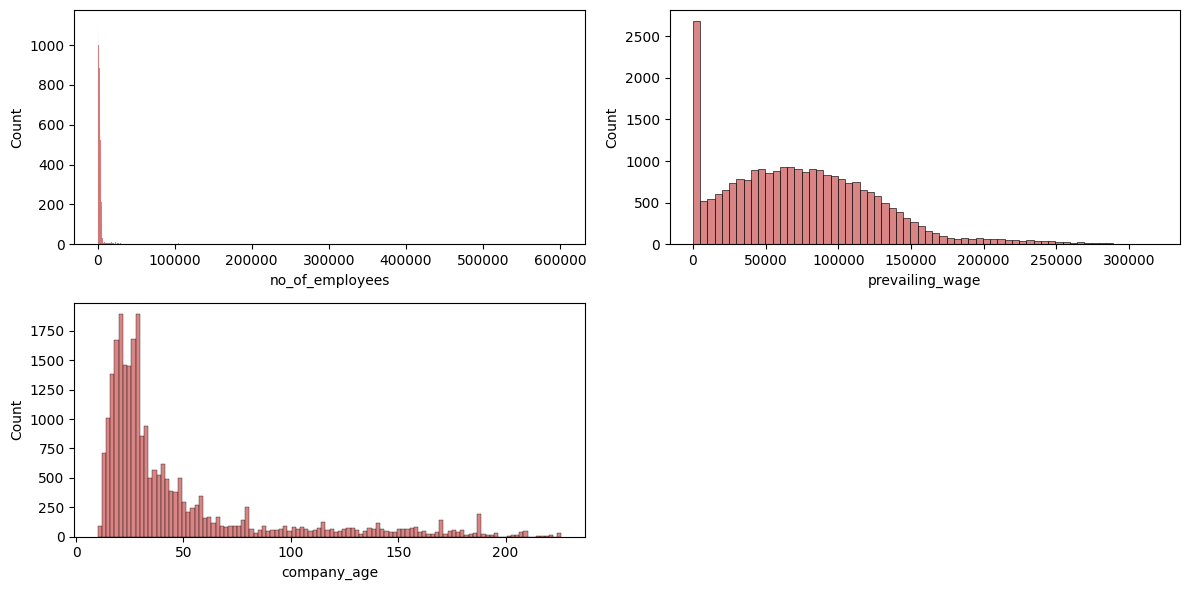

In [23]:

plt.figure(figsize=(12, 6))

for i, col in enumerate(['no_of_employees', 'prevailing_wage', 'company_age']):
    
    plt.subplot(2, 2, i + 1)
    sns.histplot(x=x[col], color='indianred')
    
    plt.xlabel(col)

plt.tight_layout()

In [24]:
x[continuous_feature].skew(axis=0,skipna=True)

no_of_employees    12.265260
prevailing_wage     0.755776
company_age         2.037301
dtype: float64

In [25]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
transform_features = ['company_age', 'no_of_employees']
X_copy = pt.fit_transform(x[transform_features])

In [26]:
X_copy = pd.DataFrame(X_copy, columns=transform_features)

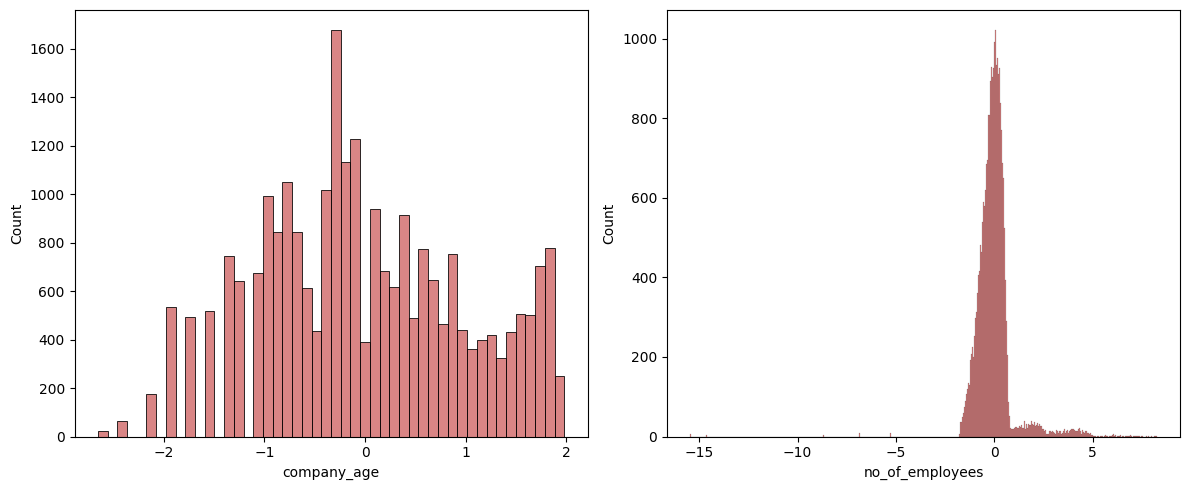

In [27]:
plt.figure(figsize=(12, 5))
for i, col in enumerate(transform_features):
    plt.subplot(1, 2, i + 1)
    sns.histplot(x=X_copy[col], color='indianred')
    plt.xlabel(col)
    plt.tight_layout()

In [28]:
X_copy.skew(axis=0,skipna=True)

company_age        0.120823
no_of_employees    0.399339
dtype: float64

In [29]:
for feature in categorical_feature:
    print(feature,':',df[feature].nunique())

continent : 6
education_of_employee : 4
has_job_experience : 2
requires_job_training : 2
region_of_employment : 5
unit_of_wage : 4
full_time_position : 2
case_status : 2


In [30]:
num_features = list(x.select_dtypes(exclude="object").columns)

In [31]:
num_features

['no_of_employees', 'prevailing_wage', 'company_age']

In [32]:

or_columns = [
    'has_job_experience',
    'requires_job_training',
    'full_time_position',
    'education_of_employee'
]

oh_columns = [
    'continent',
    'unit_of_wage',
    'region_of_employment'
]

transform_columns = ['no_of_employees', 'company_age']

num_features = ['prevailing_wage']  



from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline



numeric_transformer = StandardScaler()

oh_transformer = OneHotEncoder(handle_unknown='ignore')

ordinal_encoder = OrdinalEncoder()

transform_pipe = Pipeline(steps=[
    ('transformer', PowerTransformer(method='yeo-johnson'))
])


preprocessor = ColumnTransformer(
    transformers=[
        ("OneHotEncoder", oh_transformer, oh_columns),
        ("Ordinal_Encoder", ordinal_encoder, or_columns),
        ("Transformer", transform_pipe, transform_columns),
        ("StandardScaler", numeric_transformer, num_features)
    ]
)


In [33]:
X = preprocessor.fit_transform(x)

In [34]:
X

array([[ 0.        ,  1.        ,  0.        , ...,  1.51729976,
        -0.95850606, -1.39853722],
       [ 0.        ,  1.        ,  0.        , ...,  0.03091211,
        -0.47081562,  0.1698353 ],
       [ 0.        ,  1.        ,  0.        , ...,  2.88507606,
        -1.08047911,  0.91907852],
       ...,
       [ 0.        ,  1.        ,  0.        , ..., -0.41388512,
         1.552921  ,  1.36027953],
       [ 0.        ,  1.        ,  0.        , ..., -0.11194883,
         1.68577154,  0.22150859],
       [ 0.        ,  1.        ,  0.        , ...,  0.21874168,
         1.03193666, -0.06776315]])

In [35]:
from imblearn.combine import SMOTETomek,SMOTEENN

smt = SMOTEENN(random_state=42,sampling_strategy='minority')

X_res,y_res = smt.fit_resample(X,y)

In [36]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X_res,y_res,test_size=0.2,random_state=42)

In [37]:
X_train.shape,X_test.shape

((13648, 22), (3413, 22))

In [38]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import pandas as pd


In [39]:
def evaluate_clf(true, predicted):
    acc = accuracy_score(true, predicted)
    f1 = f1_score(true, predicted)
    precision = precision_score(true, predicted)
    recall = recall_score(true, predicted)
    roc_auc = roc_auc_score(true, predicted)

    return acc, f1, precision, recall, roc_auc



In [40]:
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(),
    "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(),
    "CatBoost Classifier": CatBoostClassifier(verbose=False),
    "Support Vector Classifier": SVC(probability=True),
    "AdaBoost Classifier": AdaBoostClassifier()
}

In [41]:
def evaluate_models(X, y, models):

    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    models_list = []
    accuracy_list = []
    auc_list = []

    for i in range(len(list(models))):

        model = list(models.values())[i]

        
        model.fit(X_train, y_train)

        
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        
        train_acc, train_f1, train_precision, train_recall, train_auc = evaluate_clf(
            y_train, y_train_pred
        )

        
        test_acc, test_f1, test_precision, test_recall, test_auc = evaluate_clf(
            y_test, y_test_pred
        )

        print(list(models.keys())[i])
        models_list.append(list(models.keys())[i])

        print("Model performance for Training set")
        print(f"- Accuracy: {train_acc:.4f}")
        print(f"- F1 score: {train_f1:.4f}")
        print(f"- Precision: {train_precision:.4f}")
        print(f"- Recall: {train_recall:.4f}")
        print(f"- ROC AUC: {train_auc:.4f}")

        print("----------------------------------")

        print("Model performance for Test set")
        print(f"- Accuracy: {test_acc:.4f}")
        print(f"- F1 score: {test_f1:.4f}")
        print(f"- Precision: {test_precision:.4f}")
        print(f"- Recall: {test_recall:.4f}")
        print(f"- ROC AUC: {test_auc:.4f}")

        print("=" * 35)
        print("\n")

        accuracy_list.append(test_acc)
        auc_list.append(test_auc)

    
    report = pd.DataFrame({
        "Model Name": models_list,
        "Accuracy": accuracy_list,
        "ROC-AUC": auc_list
    }).sort_values(by="Accuracy", ascending=False)

    return report



In [42]:
base_model_report = evaluate_models(X=X_res, y=y_res, models=models)

Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- ROC AUC: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9561
- F1 score: 0.9590
- Precision: 0.9596
- Recall: 0.9585
- ROC AUC: 0.9559


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- ROC AUC: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9194
- F1 score: 0.9247
- Precision: 0.9275
- Recall: 0.9219
- ROC AUC: 0.9192


Gradient Boosting
Model performance for Training set
- Accuracy: 0.8888
- F1 score: 0.8967
- Precision: 0.8964
- Recall: 0.8970
- ROC AUC: 0.8882
----------------------------------
Model performance for Test set
- Accuracy: 0.8793
- F1 score: 0.8863
- Precision: 0.8962
- Recall: 0.8766
- ROC AUC: 0.8795


Logistic Regression
Model performance for Training set
- Accuracy: 0.7324
- F1 score: 0

In [43]:
base_model_report

,Model Name,Accuracy,ROC-AUC
0,Random Forest,0.956050,0.955855
4,K-Neighbors Classifier,0.936127,0.934826
5,XGBClassifier,0.931439,0.931586
6,CatBoost Classifier,0.923821,0.924533
1,Decision Tree,0.919426,0.919226
2,Gradient Boosting,0.879285,0.879495
7,Support Vector Classifier,0.874890,0.875878
8,AdaBoost Classifier,0.860533,0.860468
3,Logistic Regression,0.723996,0.724012


In [44]:
xgboost_params = {
    "max_depth": range(3, 10, 2),
    "min_child_weight": range(1, 6, 2)
}


rf_params = {
    "max_depth": [10, 12, None, 15, 20],
    "max_features": ['sqrt', 'log2', None],
    "n_estimators": [10, 50, 100, 200]
}


knn_params = {
    "algorithm": ['auto', 'ball_tree', 'kd_tree', 'brute'],
    "weights": ['uniform', 'distance'],
    "n_neighbors": [3, 4, 5, 7, 9]
}

In [45]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

randomcv_models = [
    ("XGBoost", XGBClassifier(use_label_encoder=False, eval_metric='logloss'), xgboost_params),
    ("RF", RandomForestClassifier(), rf_params),
    ("KNN", KNeighborsClassifier(), knn_params)
]

In [46]:
from sklearn.model_selection import RandomizedSearchCV
model_param = {}

for name, model, params in randomcv_models:
    
    random = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=100,
        cv=3,
        verbose=2,
        n_jobs=-1,
        random_state=42
    )
    
    random.fit(X_res, y_res)
    model_param[name] = random.best_params_
    
for model_name in model_param:
    print(f"\n---------------- Best Params for {model_name} ----------------")
    print(model_param[model_name])

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Fitting 3 folds for each of 40 candidates, totalling 120 fits

---------------- Best Params for XGBoost ----------------
{'min_child_weight': 1, 'max_depth': 9}

---------------- Best Params for RF ----------------
{'n_estimators': 200, 'max_features': 'log2', 'max_depth': None}

---------------- Best Params for KNN ----------------
{'weights': 'distance', 'n_neighbors': 4, 'algorithm': 'auto'}


In [48]:
model_param

{'XGBoost': {'min_child_weight': 1, 'max_depth': 9},
 'RF': {'n_estimators': 200, 'max_features': 'log2', 'max_depth': None},
 'KNN': {'weights': 'distance', 'n_neighbors': 4, 'algorithm': 'auto'}}

In [49]:
from sklearn.metrics import roc_auc_score,roc_curve
best_models = {
    "Random Forest": RandomForestClassifier(**model_param['RF']),
    "KNeighborsClassifier": KNeighborsClassifier(**model_param['KNN']),
    "XGBoost": XGBClassifier(**model_param['XGBoost'], n_jobs=-1,)
}

tuned_report = evaluate_models(X=X_res, y=y_res, models=best_models)

Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- ROC AUC: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9561
- F1 score: 0.9589
- Precision: 0.9616
- Recall: 0.9563
- ROC AUC: 0.9560


KNeighborsClassifier
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- ROC AUC: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9651
- F1 score: 0.9678
- Precision: 0.9588
- Recall: 0.9771
- ROC AUC: 0.9642


XGBoost
Model performance for Training set
- Accuracy: 0.9992
- F1 score: 0.9993
- Precision: 0.9989
- Recall: 0.9996
- ROC AUC: 0.9992
----------------------------------
Model performance for Test set
- Accuracy: 0.9467
- F1 score: 0.9501
- Precision: 0.9538
- Recall: 0.9465
- ROC AUC: 0.9467




In [50]:
tuned_report

,Model Name,Accuracy,ROC-AUC
1,KNeighborsClassifier,0.965133,0.964185
0,Random Forest,0.956050,0.956028
2,XGBoost,0.946674,0.946688


In [52]:
best_model = KNeighborsClassifier(**model_param['KNN'])
best_model = best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
score = accuracy_score(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print("Final model KNN")
print(f"Accuracy: {score:.4f}")
print(f"Classification Report:{cr}")

Final model KNN
Accuracy: 0.9651
Classification Report:              precision    recall  f1-score   support

           0       0.97      0.95      0.96      1581
           1       0.96      0.98      0.97      1832

    accuracy                           0.97      3413
   macro avg       0.97      0.96      0.96      3413
weighted avg       0.97      0.97      0.97      3413



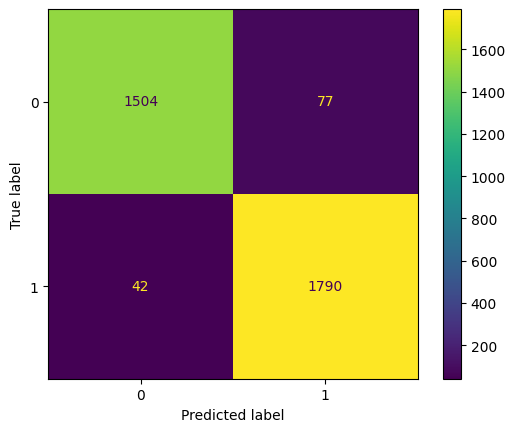

In [53]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)